In [1]:
from deap import creator, base, tools, algorithms
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from functools import partial
from datetime import datetime, timedelta

random.seed(42)
np.random.seed(42)

# Загрузка и предобработка данных

In [ ]:
df = pd.read_csv('D:\Python\РЗС\data\Automated_RSZ_distribution_enc.csv', sep=';')
df = df.sort_values(['№ схемы/риска', 'Дата изменения статуса РСЗ'])

C:\Users\zincc\AppData\Local\Temp\ipykernel_5632\2901426161.py:1: DtypeWarning: Columns (5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('D:\Python\РЗС\Automated_RSZ_distribution_enc.csv', sep=';')


In [3]:
drop_list = df[(df['Инспектор, сменивший статус'].isna()) & (df['Статус РСЗ'] != 'Новое')]['№ схемы/риска'].unique()
df = df.drop(index=df[df['№ схемы/риска'].isin(drop_list)].index)
df.loc[df['Код НО инспектора, сменившего стат']=='000n', 'Код НО инспектора, сменившего стат'] = 0

In [4]:
df.drop_duplicates(inplace=True)
df['Дата выявления'] = pd.to_datetime(df['Дата выявления'], format='%Y-%m-%d %H:%M:%S')
df['Дата изменения статуса РСЗ'] = pd.to_datetime(df['Дата изменения статуса РСЗ'], format='%Y-%m-%d %H:%M:%S')
df['Код НО инспектора, сменившего стат'] = df['Код НО инспектора, сменившего стат'].astype(int)

In [5]:
print("Общая информация о данных:")
print(f'Общее количество записей: {df.__len__()}')
print(f'Столбцы: {df.columns.to_list()}')

# Анализ статусов
print("\nРаспределение по статусам:")
print(df['Статус РСЗ'].value_counts())

# Анализ типов задач
print("\nРаспределение по типам:")
print(df['Тип'].value_counts())

Общая информация о данных:
Общее количество записей: 1373796
Столбцы: ['№ схемы/риска', 'Тип', 'Дата выявления', 'Статус РСЗ', 'Дата изменения статуса РСЗ', 'Инспектор, сменивший статус', 'Код НО инспектора, сменившего стат', 'Потенциальный ущерб, руб', 'Номер проверки', 'ИНН НП', 'КПП', 'Наименование НП', 'Рег. номер декларации', 'Код периода', 'Период', 'Год декларации', 'Номер корректировки', 'Дата подачи декларации', 'Вид налога', 'Тип декларации', 'Дата обновления', 'Дата аннулирования НД', 'Дата окончания КНП']

Распределение по статусам:
Статус РСЗ
В работе                                                 563008
Новое                                                    331589
Нарушение подтверждено. Устранено уточнением сведений    161373
Нарушение не подтверждено                                128759
Нарушение подтверждено. Доказано                          62001
Установлены отрицательные изменения                       59883
Нарушение подтверждено. Не доказано                   

In [6]:
# Анализ инспекторов
print('Распределение по инспекторам')
print(df['Инспектор, сменивший статус'].value_counts())

Распределение по инспекторам
Инспектор, сменивший статус
30250-fzog-omkeqi-eoszfzxy    42098
75845-oadk-xuuthe-iorbemnl    13638
56214-vxdc-qmbdkl-lgvrvnzm     7195
99404-xycu-argxqc-vbquafed     5432
33199-xfft-ohhuuq-yhngrscb     5104
                              ...  
53080-pmcv-dkcfvg-fnapfwfa        1
20297-thuo-ejvlfl-ylwhhrlj        1
79662-kvdb-cccfbk-uhguuekp        1
71328-fgit-apqqzm-yvciojaw        1
82985-cqdf-pxgqoq-dmckiobz        1
Name: count, Length: 12631, dtype: int64


In [7]:
df['Тип'] = df['Тип'].replace(
    to_replace={
        'Риск_долго': 'RISK_LONG',
        'Риск_быстро': 'RISK_SHORT',
        'Схема': 'SCHEMA', 
        'Задание': 'Task'
    },
    regex=True)

In [8]:
# анализ количества новых задач
# grouped_analiz_df = df.groupby('№ схемы/риска')[['Статус РСЗ', 'Тип', 'Инспектор, сменивший статус']].last()
# grouped_analiz_df[grouped_analiz_df['Статус РСЗ'] == 'Новое']

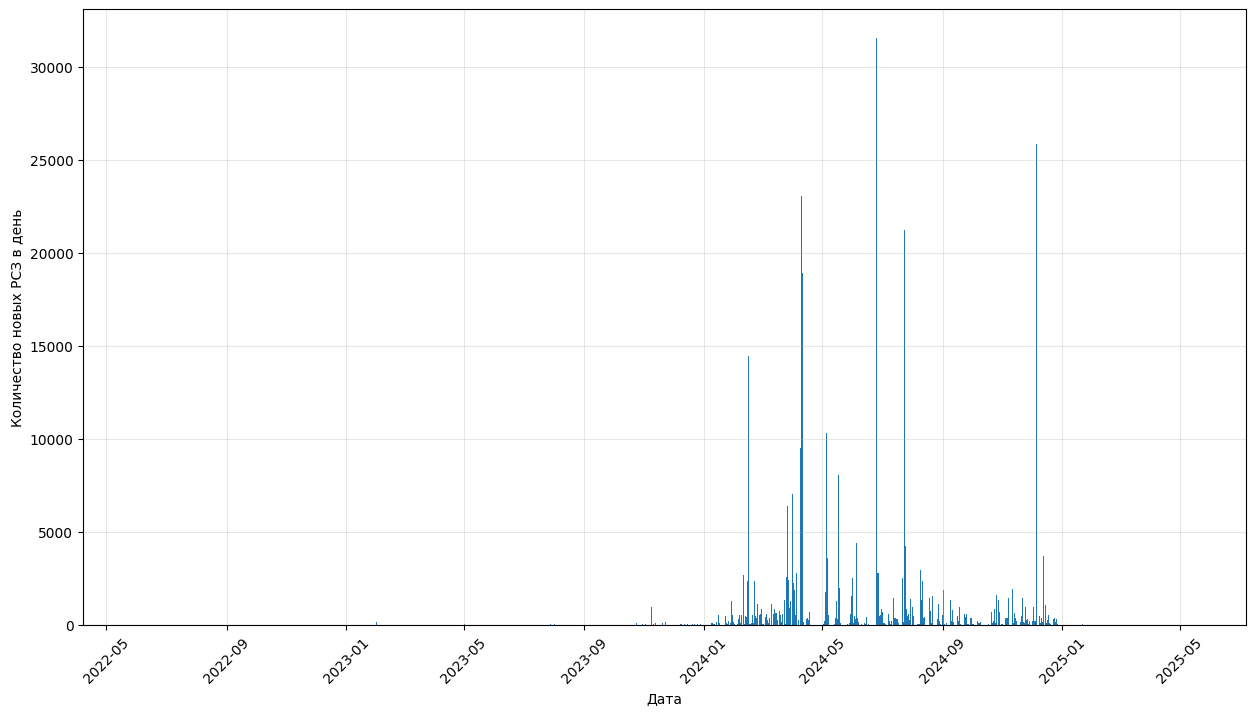

In [11]:
cloned_df = df.copy()
cloned_df = cloned_df[cloned_df['Статус РСЗ'] == 'Новое']
cloned_df['Дата'] = cloned_df['Дата изменения статуса РСЗ'].dt.date
# cloned_df = cloned_df[cloned_df['Дата изменения статуса РСЗ'] > '2024-06-01 00:00:00']
# cloned_df = cloned_df[cloned_df['Дата изменения статуса РСЗ'] < '2024-07-01 00:00:00']
bar_df = cloned_df.groupby('Дата')['Статус РСЗ'].count()
plt.figure(figsize=(15, 8))
plt.bar(x=bar_df.index, height=bar_df, width=1)
plt.xticks(rotation=45)
plt.ylabel('Количество новых РСЗ в день')
plt.xlabel('Дата')
plt.grid(True, alpha=0.3)
# plt.ylim(0, 100)

In [12]:
cloned_df
daily_counts = cloned_df[['№ схемы/риска', 'Дата изменения статуса РСЗ']].set_index('Дата изменения статуса РСЗ').resample('D').size().reset_index(name='count')
daily_counts['year'] = daily_counts['Дата изменения статуса РСЗ'].dt.year
daily_counts

daily_counts.groupby('year').agg(
    total_tasks=('count', 'sum'),
    max_daily_tasks=('count', 'max'),
    avg_daily_tasks=('count', 'mean')
).reset_index()

,year,total_tasks,max_daily_tasks,avg_daily_tasks
0,2022,82,32,0.383178
1,2023,3479,965,9.531507
2,2024,327950,31512,896.038251
3,2025,78,37,0.582090


In [13]:
# аrtifacts_list =  [7811755,  9346950,  9430063,  9446746,  9448905,  9451172,  9951162,
#        10280672, 10297671, 10304978, 11646767, 13341131, 14949625, 15158496,
#        15179189, 15256689, 15357780]
# df[df['№ схемы/риска'] == 9451172]

## Распределение баллов по задачам и инспекторам в соответствии с автостатусами

In [13]:
copy_df = df.copy()

In [14]:
# 20% в новое
def get_new_type_data(day: str = '2024-06-27', df: pd.DataFrame = copy_df):
    # df = df.sort_values(['№ схемы/риска', 'Дата изменения статуса РСЗ'])
    day += ' 00:00:00'
    date_format = '%Y-%m-%d %H:%M:%S'
    day_str = datetime.strptime(day, date_format)
    day_before_str = day_str - timedelta(days=1)
    
    day_df = df[df['Дата изменения статуса РСЗ'] <= day_str]    

    cutten_day_df = day_df[day_df['Дата изменения статуса РСЗ'] > day_before_str]
    new_tasks_df = cutten_day_df[cutten_day_df['Статус РСЗ'] == 'Новое'].groupby('№ схемы/риска')[['Статус РСЗ', 'Тип', 'Дата изменения статуса РСЗ', 'Потенциальный ущерб, руб', 'ИНН НП']].last()
    
    inwork_tasks_df = df[df['Дата изменения статуса РСЗ'] <= day_before_str].groupby('№ схемы/риска')[['Статус РСЗ', 'Тип', 'Инспектор, сменивший статус', 'Код НО инспектора, сменившего стат', 'Дата изменения статуса РСЗ', 'Потенциальный ущерб, руб', 'ИНН НП']].last()
    new_tasks_df = pd.concat([new_tasks_df, inwork_tasks_df[inwork_tasks_df['Статус РСЗ'] == 'Новое']])
    new_tasks_df.drop(columns=['Инспектор, сменивший статус', 'Код НО инспектора, сменившего стат'], inplace=True)
    inwork_tasks_df = inwork_tasks_df[inwork_tasks_df['Статус РСЗ'] != 'Новое']
    finish_tasks_df = inwork_tasks_df[inwork_tasks_df['Статус РСЗ'] != 'В работе']
    inwork_tasks_df = inwork_tasks_df[inwork_tasks_df['Статус РСЗ'] == 'В работе']
    
    return new_tasks_df, inwork_tasks_df, finish_tasks_df

In [15]:
new_tasks_df, inwork_tasks_df, finish_tasks_df = get_new_type_data('2024-06-27')

In [16]:
# Автораздача РСЗ по ИНН
inn_df = inwork_tasks_df.groupby('ИНН НП')[['Инспектор, сменивший статус', 'Код НО инспектора, сменившего стат']].last() #Большая заглушка не все работы с одним ИНН идут одному работнику. Даже ни в один ТНО порой. Пример ИНН: 972-qyi-xxuq-qkjkk
auto_dis = new_tasks_df.merge(inn_df, how='inner', left_on='ИНН НП', right_index=True)
auto_dis['Статус РСЗ'] = auto_dis['Статус РСЗ'].replace('Новое', 'В работе')
inwork_tasks_df = pd.concat([inwork_tasks_df, auto_dis])
new_tasks_df.drop(index=auto_dis.index, inplace=True)
auto_dis

,Статус РСЗ,Тип,Дата изменения статуса РСЗ,"Потенциальный ущерб, руб",ИНН НП,"Инспектор, сменивший статус","Код НО инспектора, сменившего стат"
№ схемы/риска,,,,,,,
6750711,В работе,SCHEMA,2024-06-26 03:04:28,15874338.0,379-ile-fzef-iujzv,57803-sqnl-gwvmnj-uqvvyzki,7708
7696445,В работе,SCHEMA,2024-06-26 03:04:28,15874338.0,379-ile-fzef-iujzv,57803-sqnl-gwvmnj-uqvvyzki,7708
7807914,В работе,RISK_SHORT,2024-06-26 12:22:00,2240982.2,750-vdi-otro-pvugc,51465-moum-qjwvyg-ccddrmiq,4300
8655780,В работе,RISK_SHORT,2024-06-26 22:39:18,1225448.0,901-rlu-yhcx-ejmrz,81591-piom-czhlxo-aawpfqte,7100
9366155,В работе,SCHEMA,2024-06-26 03:04:28,15874338.0,379-ile-fzef-iujzv,57803-sqnl-gwvmnj-uqvvyzki,7708
...,...,...,...,...,...,...,...
9370284,В работе,RISK_SHORT,2024-06-13 06:30:27,249371.0,286-qow-nqlq-tvcdu,81781-pryv-kxalnx-kcrzfxrt,900
9384428,В работе,RISK_SHORT,2024-06-15 04:31:56,43664.0,706-qiz-ebep-pohao,38450-frov-dxzgvf-fftbutyq,500
9418395,В работе,SCHEMA,2024-06-25 17:30:21,1126256.0,270-jkk-zaic-brscf,12738-uehh-yrpezh-cwlmyqkm,7842


In [17]:
print('Число новых РСЗ поступивших в этот день в налоговую:', len(new_tasks_df))

Число новых РСЗ поступивших в этот день в налоговую: 31563


In [18]:
Auto_Stats = pd.DataFrame({
 'Новое':                                                   [0, 0, 0, 0],
 'В работе':                                                [0, 0, 0, 0],
 'Нарушение подтверждено. Устранено уточнением сведений':   [100, 86, 46, 0],
 'Нарушение не подтверждено':                               [50, 43, 23 , 0],
 'Нарушение подтверждено. Доказано':                        [75, 65, 35, 0],
 'Установлены отрицательные изменения':                     [0, 0, 0, 0],
 'Нарушение подтверждено. Не доказано':                     [40, 34, 18, 0],
 'Не доказано':                                             [40, 34, 18, 0],
 'Декларация аннулирована':                                 [60, 52, 28, 0],
 'Разакцептование':                                         [0, 0, 0, 0],
 'Архив':                                                   [0, 0, 0, 0],
 'Ожидает обработки':                                       [0, 0, 0, 0],
 'Разакцептован':                                           [0, 0, 0, 0],
 'На проверке':                                             [0, 0, 0, 0],
 'Выполнено':                                               [0, 0, 0, 3], 
 'Не выполнено':                                            [0, 0, 0, 0],
}).transpose()
Auto_Stats.columns = ['SCHEMA', 'RISK_LONG', 'RISK_SHORT', 'TASK']

In [19]:
all_scores = [Auto_Stats.loc[stat, df.iloc[i, 1]] for i, stat in enumerate(finish_tasks_df['Статус РСЗ'])]
finish_tasks_df['Score'] = all_scores
finish_tasks_df

,Статус РСЗ,Тип,"Инспектор, сменивший статус","Код НО инспектора, сменившего стат",Дата изменения статуса РСЗ,"Потенциальный ущерб, руб",ИНН НП,Score
№ схемы/риска,,,,,,,,
4944803,Архив,RISK_LONG,84725-ywzo-dwypzb-dkqyibvy,7727,2024-03-01 12:42:21,33024.00,951-jcj-ovsl-xexdz,0
4950646,Архив,RISK_LONG,65221-yoto-fpnfvk-ljuqhapf,7000,2024-06-19 04:23:42,10158.48,931-jab-mmsl-gblig,0
4950777,Нарушение подтверждено. Доказано,RISK_LONG,20348-icof-oamlkh-idstpyvq,6316,2024-04-17 08:06:41,259009.60,378-uui-bxkr-yhlem,65
4951607,Нарушение не подтверждено,RISK_LONG,48306-zpes-keykzc-tzlhtgvc,6316,2024-04-17 08:07:22,162533.17,526-nfc-mawy-ugjmj,43
4952608,Нарушение не подтверждено,RISK_SHORT,80972-fkff-abpanr-jrhrknmk,5100,2022-01-24 08:15:40,73335.50,888-loq-kczq-swdov,43
...,...,...,...,...,...,...,...,...
9413623,Нарушение подтверждено. Доказано,RISK_LONG,81218-uhae-lhjrkn-hgzbgeat,6700,2024-06-18 17:02:31,1997.00,707-wnm-ldaf-wgjlb,65
9413685,Нарушение подтверждено. Не доказано,RISK_SHORT,66206-dlct-jkilhg-xezazvxq,4800,2024-06-25 15:12:51,84843.00,276-luf-wlbz-bwzde,18
9413862,Нарушение не подтверждено,RISK_SHORT,76728-ectf-oanuyq-xhwjwilt,7452,2024-06-18 10:30:24,166667.00,293-ybb-lccj-wtucz,23


In [22]:
N_ended_works = finish_tasks_df.groupby('Инспектор, сменивший статус')['Score'].count()
N_ended_works

Инспектор, сменивший статус
11111-iyri-uwwjst-chzuradt    38
11125-pwzz-fygsdc-pkejzjik     3
11131-sfab-goldts-zajlmqic     1
11144-drfl-uxzbft-hnxymdov     4
11154-slzs-ahaxfb-jabdsspi     2
                              ..
99958-muml-yjokvs-nqgsmcoi     1
99962-xuim-lxusxl-liyswlzm     1
99969-qxfc-eirral-zrzcrexd    23
99981-ohqn-cntirp-negogxqs     5
99989-hjji-oyrmzp-aizmuiyk     8
Name: Score, Length: 8761, dtype: int64

## Создание датасета о инструктарах

In [23]:
new_inspectots_df = pd.read_excel('D:\Python\РЗС\Результативность.xlsx')#, header=[0, 1])
new_inspectots_df.columns = new_inspectots_df.columns[:3].to_list() + new_inspectots_df.loc[0, :].to_list()[3:]
new_inspectots_df.drop(index=0, inplace=True)
new_inspectots_df.reset_index(drop=True, inplace=True)
new_inspectots_df

,ФИО,Текущая должность,Общий стаж,1 кв 2022,2 кв 2022,3 кв 2022,4 кв 2022,1 кв 2023,2 кв 2023,3 кв 2023,4 кв 2023,1 кв 2024,2 кв 2024,3 кв 2024,4 кв 2024,1 кв 2025,2 кв 2025
0,40909-qbax-xesvrt-bklmoiht,Главный государственный налоговый инспектор,34 года,0,0.9,3.130438,8.415363,0,0,0,0,0,0,0,0,0,0
1,86931-qzbp-edluqo-jdvmbxed,Главный государственный налоговый инспектор,17 лет 9 месяцев,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,33882-knmm-wahroo-xlakzbix,Заместитель начальника инспекции,40 лет 7 месяцев,0,0,0.332609,0,0,0,0,0,0,0,0,0,0,0
3,44235-ileb-vswfpu-suallnet,Государственный налоговый инспектор,14 лет 10 месяцев,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,40458-ulye-qdmaam-ptnutpmf,Начальник отдела,20 лет 6 месяцев,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4737,11241-dcjo-hrzfup-zzlktiya,Старший специалист 2 разряда,29 лет 9 месяцев,0,0,0,0,0.485393,0,0,1.427587,0,3.750699,0,0,1.193684,2.570479
4738,11225-cvmq-gkzxrh-afonkfdt,Старший государственный налоговый инспектор,12 лет 11 месяцев,0,0,1.377907,4.992587,0.246857,2.932343,2.177419,1.070632,0,3.955955,7.31214,4.96925,1.344001,0.28125
4739,11132-fgon-zinrmu-koxfcmwo,Старший государственный налоговый инспектор,21 год 10 месяцев,0,0,0,0,0,0,0,0,0,0,0,0,0.396711,0
4740,11131-sfab-goldts-zajlmqic,старший государственный налоговый инспектор,3 года 5 месяцев,0,0,1.018705,1.388465,2.571429,0.960736,2.612528,0.962609,0.9,0,5.694857,2.076489,3.484495,0.27


In [24]:
# import re
pattern = r'((?P<years>\d{1,2})\s*(?:год[ау]?|лет|г\.?))|((?P<months>\d{1,2})\s*(?:месяц[аев]?|мес\.?)|(?P<half_year>полгода))'
# new_inspectots_df['Общий стаж'].str.extract(r'((?P<years>\d{1,2})\s*(?:год[ау]?|лет|г\.?))|((?P<months>\d{1,2})\s*(?:месяц[аев]?|мес\.?))')
# new_inspectots_df['Общий стаж'].str.extract(r'((?P<months>\d{1,2})\s*(?:месяц[аев]?|мес\.?))')
matches = new_inspectots_df['Общий стаж'].str.extractall(pattern).groupby(level=0).agg({
    'years': 'first', 
    'months': 'first',
    'half_year': 'first'
})

# Заменяем "полгода" на 6 месяцев
matches.loc[matches['half_year'].notna(), 'months'] = '6'

new_inspectots_df['years'] = pd.to_numeric(matches['years'], errors='coerce').fillna(0)
new_inspectots_df['months'] = pd.to_numeric(matches['months'], errors='coerce').fillna(0)
new_inspectots_df

,ФИО,Текущая должность,Общий стаж,1 кв 2022,2 кв 2022,3 кв 2022,4 кв 2022,1 кв 2023,2 кв 2023,3 кв 2023,4 кв 2023,1 кв 2024,2 кв 2024,3 кв 2024,4 кв 2024,1 кв 2025,2 кв 2025,years,months
0,40909-qbax-xesvrt-bklmoiht,Главный государственный налоговый инспектор,34 года,0,0.9,3.130438,8.415363,0,0,0,0,0,0,0,0,0,0,34,0.0
1,86931-qzbp-edluqo-jdvmbxed,Главный государственный налоговый инспектор,17 лет 9 месяцев,0,0,0,0,0,0,0,0,0,0,0,0,0,0,17,9.0
2,33882-knmm-wahroo-xlakzbix,Заместитель начальника инспекции,40 лет 7 месяцев,0,0,0.332609,0,0,0,0,0,0,0,0,0,0,0,40,7.0
3,44235-ileb-vswfpu-suallnet,Государственный налоговый инспектор,14 лет 10 месяцев,0,0,0,0,0,0,0,0,0,0,0,0,0,0,14,10.0
4,40458-ulye-qdmaam-ptnutpmf,Начальник отдела,20 лет 6 месяцев,0,0,0,0,0,0,0,0,0,0,0,0,0,0,20,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4737,11241-dcjo-hrzfup-zzlktiya,Старший специалист 2 разряда,29 лет 9 месяцев,0,0,0,0,0.485393,0,0,1.427587,0,3.750699,0,0,1.193684,2.570479,29,9.0
4738,11225-cvmq-gkzxrh-afonkfdt,Старший государственный налоговый инспектор,12 лет 11 месяцев,0,0,1.377907,4.992587,0.246857,2.932343,2.177419,1.070632,0,3.955955,7.31214,4.96925,1.344001,0.28125,12,11.0
4739,11132-fgon-zinrmu-koxfcmwo,Старший государственный налоговый инспектор,21 год 10 месяцев,0,0,0,0,0,0,0,0,0,0,0,0,0.396711,0,21,10.0
4740,11131-sfab-goldts-zajlmqic,старший государственный налоговый инспектор,3 года 5 месяцев,0,0,1.018705,1.388465,2.571429,0.960736,2.612528,0.962609,0.9,0,5.694857,2.076489,3.484495,0.27,3,5.0


In [25]:
new_inspectots_df['Текущая должность'] = new_inspectots_df['Текущая должность'].str.lower()
new_inspectots_df['Текущая должность'] = new_inspectots_df['Текущая должность'].str.replace("  ", " ")
new_inspectots_df['Текущая должность'] = new_inspectots_df['Текущая должность'].str.replace(" -", "-")
new_inspectots_df['Текущая должность'] = new_inspectots_df['Текущая должность'].str.replace("p", "р")
new_inspectots_df['Текущая должность'] = new_inspectots_df['Текущая должность'].str.replace("c", "с")
new_inspectots_df['Текущая должность'].unique().tolist()

['главный государственный налоговый инспектор',
 'заместитель начальника инспекции',
 'государственный налоговый инспектор',
 'начальник отдела',
 'специалист 1 разряда',
 'старший государственный налоговый инспектор',
 'заместитель начальника',
 'специалист-эксперт',
 'заместитель начальника отдела',
 'и.о. заместителя начальника отдела',
 'заместитель руководителя',
 'старший специалист 2 разряда',
 'ведущий специалист-эксперт',
 nan,
 'главный специалист-эксперт',
 'врио заместителя руководителя',
 'старший специалист 1 разряда',
 'старший специалист 3 разряда',
 'старший инспектор-делопроизводитель',
 'ведущий эксперт']

In [26]:
new_inspectots_df[new_inspectots_df['Текущая должность'].isna()]

,ФИО,Текущая должность,Общий стаж,1 кв 2022,2 кв 2022,3 кв 2022,4 кв 2022,1 кв 2023,2 кв 2023,3 кв 2023,4 кв 2023,1 кв 2024,2 кв 2024,3 кв 2024,4 кв 2024,1 кв 2025,2 кв 2025,years,months
259,37512-jfby-npqtem-tvefnuea,NaN,8 лет 6 месяцев,0,0,6.30631,1.604285,0.445361,0,0,0,0,0,0,0,0,0,8,6.0


In [27]:
new_inspectots_df[new_inspectots_df['2 кв 2025'].isna()]

,ФИО,Текущая должность,Общий стаж,1 кв 2022,2 кв 2022,3 кв 2022,4 кв 2022,1 кв 2023,2 кв 2023,3 кв 2023,4 кв 2023,1 кв 2024,2 кв 2024,3 кв 2024,4 кв 2024,1 кв 2025,2 кв 2025,years,months
989,99989-hjji-oyrmzp-aizmuiyk,старший государственный налоговый инспектор,16 лет 6 месяцев,0,0,0,0,0,0.786885,0,0,0.255789,NaN,NaN,NaN,NaN,NaN,16,6.0


In [28]:
# copy_df[copy_df['Инспектор, сменивший статус'] == '99989-hjji-oyrmzp-aizmuiyk'].sort_values('Дата изменения статуса РСЗ')

In [28]:
new_inspectots_df['sum'] = new_inspectots_df.iloc[:, 3:17].sum(axis=1)
new_inspectots_df[new_inspectots_df['sum'] == 0]

,ФИО,Текущая должность,Общий стаж,1 кв 2022,2 кв 2022,3 кв 2022,4 кв 2022,1 кв 2023,2 кв 2023,3 кв 2023,4 кв 2023,1 кв 2024,2 кв 2024,3 кв 2024,4 кв 2024,1 кв 2025,2 кв 2025,years,months,sum
1,86931-qzbp-edluqo-jdvmbxed,главный государственный налоговый инспектор,17 лет 9 месяцев,0,0,0,0,0,0,0,0,0,0,0,0,0,0,17,9.0,0
3,44235-ileb-vswfpu-suallnet,государственный налоговый инспектор,14 лет 10 месяцев,0,0,0,0,0,0,0,0,0,0,0,0,0,0,14,10.0,0
4,40458-ulye-qdmaam-ptnutpmf,начальник отдела,20 лет 6 месяцев,0,0,0,0,0,0,0,0,0,0,0,0,0,0,20,6.0,0
5,48548-rquv-lvehvc-cxufdlxm,главный государственный налоговый инспектор,8 лет 5 месяцев,0,0,0,0,0,0,0,0,0,0,0,0,0,0,8,5.0,0
7,24254-quvd-kazfhm-abrfwkrl,специалист 1 разряда,5 лет 9 месяцев,0,0,0,0,0,0,0,0,0,0,0,0,0,0,5,9.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4501,16880-ijri-ijhltq-bidymlfj,заместитель начальника отдела,13 лет 4 месяца,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,4.0,0
4578,15030-mdpg-qmwfdr-bqfxbwms,заместитель начальника отдела,8 лет,0,0,0,0,0,0,0,0,0,0,0,0,0,0,8,0.0,0
4582,14712-bwnn-mlrexr-hkuneuqx,главный государственный налоговый инспектор,9 лет 9 месяцев,0,0,0,0,0,0,0,0,0,0,0,0,0,0,9,9.0,0
4683,12265-lwow-exglig-kzhzvtjx,заместитель начальника отдела,30 лет 8 месяцев,0,0,0,0,0,0,0,0,0,0,0,0,0,0,30,8.0,0


In [29]:
inspectors_df = pd.DataFrame(copy_df.groupby('Инспектор, сменивший статус')['Код НО инспектора, сменившего стат'].last())
inspectors_efficiency = finish_tasks_df[finish_tasks_df['Score'] > 0].groupby('Инспектор, сменивший статус')['Score'].sum()/N_ended_works/100
inspectors_df = inspectors_df.merge(inspectors_efficiency, how='left', left_index=True, right_index=True)
inspectors_df.fillna(0, inplace=True)
inspectors_df['Experience'] = [np.random.random()/2 for i in range(len(inspectors_df))]
inspectors_df['Qualification'] = inspectors_df['Score'] + inspectors_df['Experience']

mask = inspectors_df['Qualification'] >= 0.71

# Используем np.where для каждого столбца
inspectors_df['p_SCHEMA'] = np.where(mask, 0.5, 0)
inspectors_df['p_RISK_LONG'] = np.where(mask, 0.5, 0)
inspectors_df['p_RISK_SHORT'] = np.where(mask, 0, 0.5)
inspectors_df['p_TASK'] = np.where(mask, 0, 0.5)


In [30]:
merged_insp_df = inspectors_df.merge(new_inspectots_df, how='inner', left_index=True, right_on='ФИО')
len(merged_insp_df)

3751

In [31]:
for no in inspectors_df['Код НО инспектора, сменившего стат'].unique():    
    a = merged_insp_df[merged_insp_df['Код НО инспектора, сменившего стат'] == no]['Код НО инспектора, сменившего стат'].count() 
    b = inspectors_df[inspectors_df['Код НО инспектора, сменившего стат'] == no]['Код НО инспектора, сменившего стат'].count()
    if a == b:
        print(no, a)

5004 1
5836 1
573 2
3327 1
572 1
3800 2
8901 1
4339 1
554 2
507 2
3328 1
5805 1
8600 1


## Подготовка нераспределённых РСЗ

In [32]:
insp_df = copy_df.groupby('№ схемы/риска')[['Инспектор, сменивший статус', 'Код НО инспектора, сменившего стат']].last()
new_tasks_df = new_tasks_df.merge(insp_df, how='left', left_index=True, right_index=True)

In [33]:
distribution_new_tasks = {'RISK_SHORT': 1, 'SCHEMA': 1, 'RISK_LONG': 1, 'TASK': 1}
distribution_new_tasks.update((k, new_tasks_df['Тип'].value_counts().to_dict()[k]) for k in set(distribution_new_tasks) & set(new_tasks_df['Тип'].value_counts().to_dict()))
distribution_new_tasks

{'RISK_SHORT': 31467, 'SCHEMA': 84, 'RISK_LONG': 12, 'TASK': 1}

In [34]:
# Функция для разбиванию инспекторов и РСЗ по НО
def filter_by_no(no_code:int, dataframe:pd.DataFrame = new_tasks_df):
    no_inspectors_df = inspectors_df[inspectors_df['Код НО инспектора, сменившего стат'] == no_code]
    no_inspectors_df["Inspector index"] = [i for i in range(len(no_inspectors_df))]
    
    # Заспределяем новые задачи по НО    
    # dataframe = dataframe.merge(inspectors_df[['Код НО инспектора, сменившего стат']], how='left', left_on='Инспектор, сменивший статус', right_index=True)
    dataframe['Код НО инспектора, сменившего стат'] = dataframe['Код НО инспектора, сменившего стат'].fillna(0).astype(int)
    no_df = dataframe[dataframe['Код НО инспектора, сменившего стат'] == no_code]
    
    return no_inspectors_df, no_df,

In [35]:
def start_data_prep(inspectors_df: pd.DataFrame, df: pd.DataFrame, in_work: pd.DataFrame = None):
    # Расчёт вероятности передачи определённого типа задачи сотруднику --> np.array(сотрудники, типы задач)
    task_prob = [inspectors_df['p_SCHEMA'].to_list(), inspectors_df['p_RISK_LONG'].to_list(), inspectors_df['p_RISK_SHORT'].to_list(), inspectors_df['p_TASK'].to_list(),]
    task_prob = np.array([*zip(*task_prob)])
    
    # Определения числа распределяемых задач и числа сотрудников --> int, int
    N, M = df.__len__(), inspectors_df.__len__()
    
    # Создание массива хранящего в себе тип задачи по порядку --> np.array(число распределяемых задач)
    if in_work is not None:
        concate_df = pd.concat([df, in_work])
    else:
        concate_df = df
    task_cat = concate_df['Тип'].to_numpy()
    
    # Создание словаря хранящего количество распределяемых задач данного типа --> dict()
    den_TNO = {'RISK_SHORT': 1, 'SCHEMA': 1, 'RISK_LONG': 1, 'TASK': 1}
    den_TNO.update((k, concate_df['Тип'].value_counts().to_dict()[k]) for k in set(den_TNO) & set(concate_df['Тип'].value_counts().to_dict()))
    
    return task_prob, N, M, task_cat, den_TNO

### Функция расчёта нагрузки и эффективности

In [36]:
def evaluation(individual: list, den_TNO: dict, task_cat: np.array, task_prob: np.array, M: int, results: bool = False, current_individ: list = []):
    full_ind = individual + current_individ
    K1, K2, K3, K4 = 100, 80, 46, 3
    K_SUM = K1 + K2 + K3 + K4
    cnt = {cat: np.zeros(M, dtype=int) for cat in den_TNO} 
    for j, emp_idx in enumerate(full_ind):
        cnt[task_cat[j]][emp_idx] += 1
        
    nu = (
        cnt["SCHEMA"]     / den_TNO["SCHEMA"]     * K1 +
        cnt["RISK_LONG"]  / den_TNO["RISK_LONG"]  * K2 +
        cnt["RISK_SHORT"] / den_TNO["RISK_SHORT"] * K3 +
        cnt["TASK"]       / den_TNO["TASK"]       * K4
    ) / K_SUM * 100
    
    
    efficiency = (
        cnt["SCHEMA"]     * task_prob[:, 0]   / den_TNO["SCHEMA"]     +
        cnt["RISK_LONG"]  * task_prob[:, 1]   / den_TNO["RISK_LONG"]  +
        cnt["RISK_SHORT"] * task_prob[:, 2]   / den_TNO["RISK_SHORT"] +
        cnt["TASK"]       * task_prob[:, 3]   / den_TNO["TASK"]       
    ).sum() *100
    
    load = nu.max()
    if not results:
        return load, efficiency,
    return nu, efficiency,

### Функция оптимизации

In [37]:
def Multi_optimization(no_code: int, population_size: int = 200, epoches: int = 200, p_crossing: float = 0.5, p_mutation: float = 0.2):
    
    no_inspectors_df, in_work_no_df = filter_by_no(no_code,  inwork_tasks_df)

    in_work_indiv = in_work_no_df.merge(no_inspectors_df[['Inspector index']], left_on='Инспектор, сменивший статус', right_index=True, how='left')
    in_work_indiv = in_work_indiv['Inspector index'].to_list()
        
    no_inspectors_df, no_df = filter_by_no(no_code)
    task_prob, N, M, task_cat, den_TNO = start_data_prep(no_inspectors_df, no_df, in_work_no_df)
        
    func = partial(evaluation, den_TNO=den_TNO, task_cat=task_cat, task_prob=task_prob, M=M, current_individ=in_work_indiv)
    
    creator.create('FintesMulti', base.Fitness, weights=(-1, 1)) # load ↓, efficiency ↑
    creator.create('Individual', list, fitness=creator.FintesMulti)
    
    toolbox = base.Toolbox()
    fit1_stats = tools.Statistics(key=lambda ind: ind.fitness.values[0])
    fit2_stats = tools.Statistics(key=lambda ind: ind.fitness.values[1])

    mstats = tools.MultiStatistics(fit1=fit1_stats, fit2=fit2_stats)
    mstats.register("min", np.min)
    mstats.register("avg", np.mean)
    mstats.register("max", np.max)

    toolbox.register('attr_int', np.random.randint, 0, M)
    toolbox.register('individual', tools.initRepeat, creator.Individual, 
                    toolbox.attr_int, N)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)
    toolbox.register("evaluate", func)
    toolbox.register("mate", tools.cxTwoPoint)
    toolbox.register('mutate', tools.mutUniformInt,  low=0, up=M-1, indpb=0.05)
    toolbox.register('select', tools.selNSGA2)
    
    hall_of_fame = tools.HallOfFame(np.inf)
    population = toolbox.population(population_size)
    pop, logbook = algorithms.eaMuPlusLambda(population, 
                                    toolbox, 
                                    mu=population_size//2,
                                    lambda_=population_size//2,
                                    cxpb=p_crossing, mutpb=p_mutation, ngen=epoches, 
                                    halloffame=hall_of_fame,
                                    stats=mstats, verbose=True)
    
    pareto = tools.sortNondominated(pop, len(pop), first_front_only=True)[0]
    uniq_pareto = []
    for ind in pareto:
        if ind not in uniq_pareto:
            uniq_pareto.append(ind)
            
    print("Len of Pareto set:", len(uniq_pareto))
    return hall_of_fame, uniq_pareto
    

## Оптимизация по выбраному НО

In [38]:
df['Код НО инспектора, сменившего стат'].nunique()

437

In [39]:
new_tasks_df[new_tasks_df['Тип']=='SCHEMA'].groupby('Код НО инспектора, сменившего стат')['Код НО инспектора, сменившего стат'].count().idxmax()

np.int64(7731)

In [40]:
inspectors_df.groupby('Код НО инспектора, сменившего стат')['Код НО инспектора, сменившего стат'].count().idxmax()

np.int64(500)

In [58]:
# no_code = new_tasks_df.groupby('Код НО инспектора, сменившего стат')['Статус РСЗ'].count().sort_values(ascending=False).index[1] #new_tasks_df['Код НО инспектора, сменившего стат'].unique()[0]
no_code = new_tasks_df[new_tasks_df['Тип']=='SCHEMA'].groupby('Код НО инспектора, сменившего стат')['Код НО инспектора, сменившего стат'].count().idxmax()
# no_code = inspectors_df.groupby('Код НО инспектора, сменившего стат')['Код НО инспектора, сменившего стат'].count().idxmax()
no_code

np.int64(7731)

In [59]:
no_inspectors_df, no_df = filter_by_no(no_code)
no_inspectors_df, in_work_no_df = filter_by_no(no_code,  inwork_tasks_df)
task_prob, N, M, task_cat, den_TNO = start_data_prep(no_inspectors_df, no_df, in_work_no_df)
hall_of_fame, uniq_pareto = Multi_optimization(no_code)

C:\Users\zincc\AppData\Local\Temp\ipykernel_5632\3402775206.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  no_inspectors_df["Inspector index"] = [i for i in range(len(no_inspectors_df))]
C:\Users\zincc\AppData\Local\Temp\ipykernel_5632\3402775206.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  no_inspectors_df["Inspector index"] = [i for i in range(len(no_inspectors_df))]
C:\Users\zincc\AppData\Local\Temp\ipykernel_5632\3402775206.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy

   	      	                 fit1                 	                 fit2                 
   	      	--------------------------------------	--------------------------------------
gen	nevals	avg    	gen	max    	min    	nevals	avg    	gen	max    	min    	nevals
0  	200   	19.0221	0  	19.8379	18.6628	200   	80.9773	0  	83.6201	78.3171	200   
1  	64    	18.979 	1  	19.6897	18.6628	64    	82.1504	1  	83.9232	79.3777	64    
2  	76    	18.9621	2  	19.7353	18.6628	76    	82.5254	2  	84.1883	79.3777	76    
3  	70    	18.9523	3  	19.7353	18.6628	70    	82.8444	3  	84.1883	80.6277	70    
4  	75    	18.8518	4  	19.6897	18.6628	75    	83.1754	4  	84.605 	81.3853	75    
5  	64    	18.8939	5  	19.6897	18.6628	64    	83.5728	5  	84.605 	82.2565	64    
6  	70    	18.8552	6  	19.644 	18.6628	70    	83.7614	6  	85.4383	82.4459	70    
7  	68    	18.8412	7  	19.8379	18.6628	68    	83.9872	7  	85.4383	82.6732	68    
8  	67    	18.8601	8  	19.8379	18.6628	67    	84.1406	8  	85.5519	82.711 	67    
9  	75    	1

In [60]:
len(no_df['ИНН НП'].unique())

190

In [61]:
len(no_df)

211

In [62]:
den_TNO

{'RISK_SHORT': 440, 'SCHEMA': 132, 'RISK_LONG': 70, 'TASK': 1}

In [63]:
no_df['Тип'].value_counts()

Тип
RISK_SHORT    189
SCHEMA         22
Name: count, dtype: int64

### Анализ существуюшей нагрузки и её эффективности

22.471131749302906


C:\Users\zincc\AppData\Local\Temp\ipykernel_5632\3402775206.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  no_inspectors_df["Inspector index"] = [i for i in range(len(no_inspectors_df))]


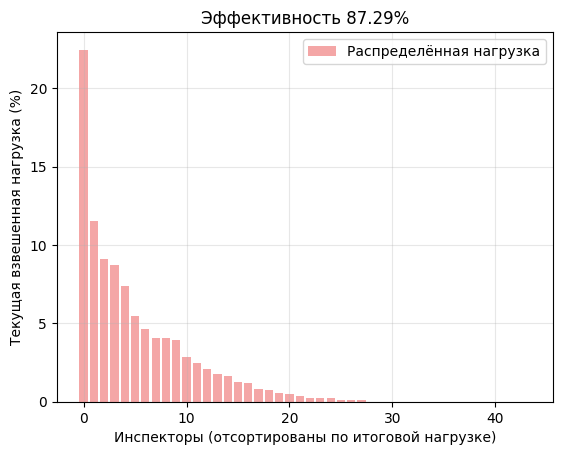

In [64]:
current_no_inspectors_df, current_no_df = filter_by_no(no_code, inwork_tasks_df)
current_task_prob, current_N, current_M, current_task_cat, current_den_TNO = start_data_prep(current_no_inspectors_df, current_no_df)
current_no_df = current_no_df.merge(current_no_inspectors_df[['Inspector index']], left_on='Инспектор, сменивший статус', right_index=True, how='left')
current_individ = current_no_df['Inspector index'].to_list()

current_load, current_eff = evaluation(current_individ, den_TNO=current_den_TNO, task_cat=current_task_cat, M=current_M, task_prob=current_task_prob, results=True)
sorted_current_load = np.sort(current_load)[::-1]
index = [i for i in range(len(current_no_inspectors_df))]

plt.bar(x=index, height=sorted_current_load, width=0.8, label='Распределённая нагрузка', color='lightcoral',  alpha = 0.7)
plt.xlabel('Инспекторы (отсортированы по итоговой нагрузке)')
plt.ylabel('Текущая взвешенная нагрузка (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title(f'Эффективность {round(current_eff, 2)}%')
print(max(current_load))

22.471131749302906


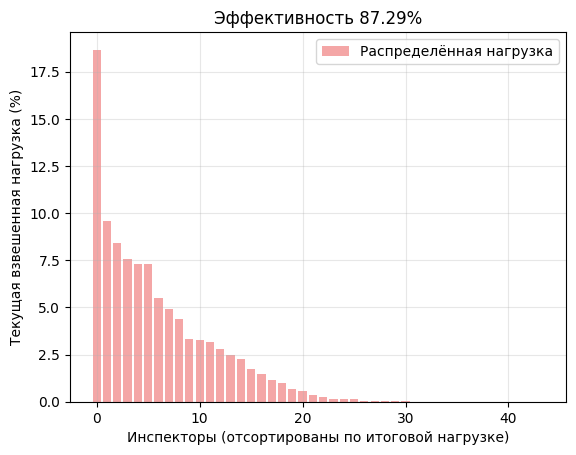

In [65]:
future_individ = no_df[['Статус РСЗ', 'Тип', 'Потенциальный ущерб, руб',	'ИНН НП', 'Инспектор, сменивший статус']].copy()
future_individ = future_individ.merge(no_inspectors_df.reset_index()[['Инспектор, сменивший статус', 'Inspector index']], how='left', left_on='Инспектор, сменивший статус', right_on='Инспектор, сменивший статус')
future_individ = future_individ['Inspector index'].to_list()
future_load, future_eff = evaluation(future_individ, den_TNO, task_cat, task_prob, M, results=True, current_individ=current_individ)
sorted_future_load = np.sort(future_load)[::-1]
index = [i for i in range(len(current_no_inspectors_df))]

plt.bar(x=index, height=sorted_future_load, width=0.8, label='Распределённая нагрузка', color='lightcoral',  alpha = 0.7)
plt.xlabel('Инспекторы (отсортированы по итоговой нагрузке)')
plt.ylabel('Текущая взвешенная нагрузка (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title(f'Эффективность {round(current_eff, 2)}%')
print(max(current_load))

### Анализ результатов оптимизации распределения новых задач

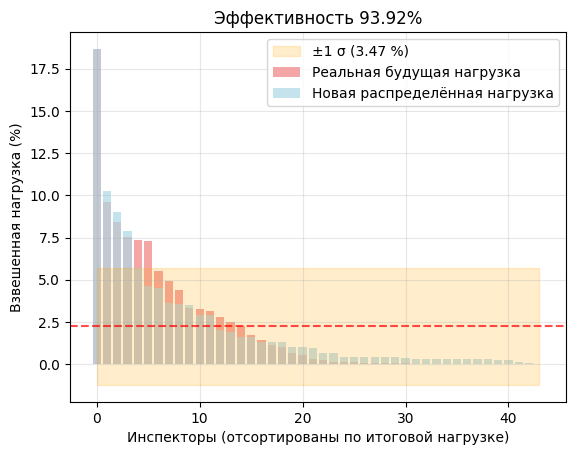

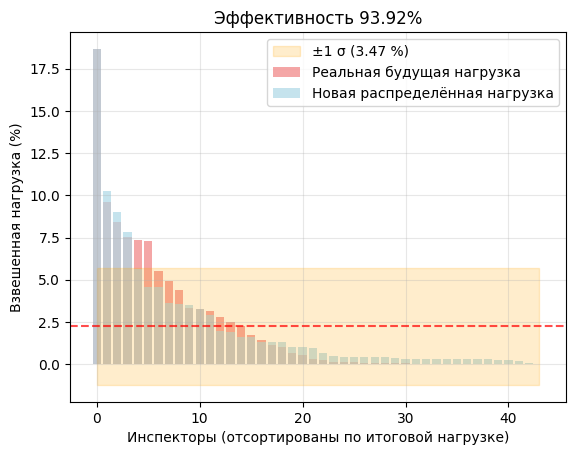

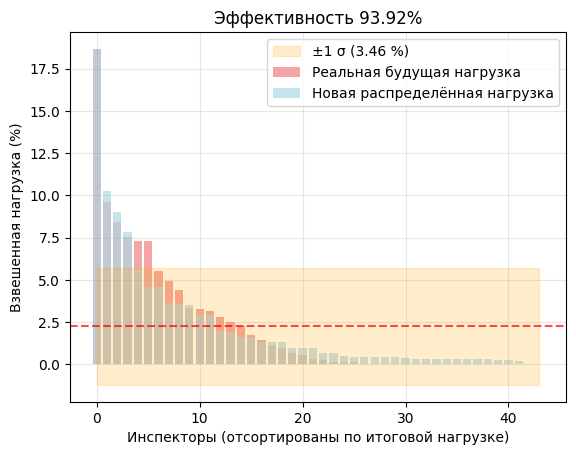

In [66]:
index = [i for i in range(len(no_inspectors_df))]
for pareto_ind in uniq_pareto:
    load, eff = evaluation(pareto_ind, den_TNO, task_cat, task_prob, M, results=True, current_individ=current_individ)
    sorted_load = np.sort(load)[::-1]
    current_mean = load.mean()
    std = load.std()    
    plt.bar(x=index, height=sorted_future_load, width=0.8, label='Реальная будущая нагрузка', color='lightcoral',  alpha = 0.7)
    # plt.bar(x=index, height=sorted_current_load, width=0.8, label='Текущая распределённая нагрузка', color='lightcoral',  alpha = 0.7)
    plt.bar(x=index, height=sorted_load, width=0.8, label='Новая распределённая нагрузка', color='lightblue',  alpha = 0.7)
    plt.axhline(y=current_mean, color='red', linestyle='--', alpha=0.7)
    plt.fill_between(x=index, y1=current_mean - std, y2=current_mean + std,
                 color="orange", alpha=0.2, label=f"±1 σ ({std:.2f} %)")
    plt.xlabel('Инспекторы (отсортированы по итоговой нагрузке)')
    plt.ylabel('Взвешенная нагрузка (%)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.title(f'Эффективность {round(eff, 2)}%')
    plt.show()
# improvement = ((current_mean - final_mean) / current_mean * 100) if current_mean > 0 else 0
# ax1.axhline(y=final_mean, color='blue', linestyle='--', alpha=0.7)

In [67]:
def huper_volum(pareto: list = uniq_pareto, r: tuple = (100,0)):
    point_sample = sorted([ind.fitness.values for ind in pareto])
    V = abs(point_sample[0][0] - r[0])*abs(point_sample[0][1] - r[1])
    for i in range(len(point_sample)-1):
        V += abs(point_sample[i][0] - point_sample[i+1][0])*abs(point_sample[i][1] - point_sample[i+1][1])
    return V

In [68]:
huper_volum(r = (100, 0))

np.float64(7639.444124366219)

In [69]:
current_load.max() - current_load.mean()

np.float64(20.228178196305684)

In [70]:
load.max() - load.mean()

np.float64(16.41987561201535)

In [71]:
all_generations = hall_of_fame.items
# all_generations.
populations = [ind.fitness.values for ind in all_generations]
populations = [[value[0], value[1]] for value in populations]
populations = [*zip(*populations)]
populations.append(tuple(all_generations))

pareto_front = [ind.fitness.values for ind in uniq_pareto]
pareto_front = [[value[0], value[1]] for value in pareto_front]
pareto_front = [*zip(*pareto_front)]
pareto_front.append(tuple(uniq_pareto))

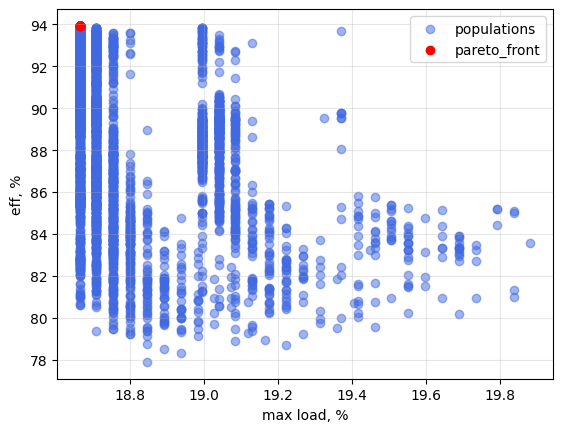

In [72]:
# vals = logbook.select("values")

# Получаем все сохраненные популяции
all_generations = hall_of_fame.items
# all_generations.
populations = [ind.fitness.values for ind in all_generations]
populations = [[value[0], value[1]] for value in populations]
populations = [*zip(*populations)]

pareto_front = [ind.fitness.values for ind in uniq_pareto]
pareto_front = [[value[0], value[1]] for value in pareto_front]
pareto_front = [*zip(*pareto_front)]

plt.scatter(populations[0], populations[1], c='royalblue', alpha=0.5)
plt.scatter(pareto_front[0], pareto_front[1], c='red')
plt.legend(['populations', 'pareto_front'])
plt.xlabel('max load, %')
plt.ylabel('eff, %')
plt.grid(True, alpha=0.3)

In [54]:
# import plotly.graph_objects as go
# from ipywidgets import Output
# import ipywidgets as widgets

# output_area = Output()

# fig = go.FigureWidget()
# # fig.update_yaxes(range=[0, 100])
# # fig.update_xaxes(range=[0, 10])
# fig.add_trace(go.Scatter(x=populations[0], y=populations[1], mode='markers',  marker_color="royalblue", name='populations', customdata=populations[2]))
# fig.add_trace(go.Scatter(x=pareto_front[0], y=pareto_front[1], mode='markers',  marker_color="Red", name='pareto front', customdata=pareto_front[2]))
# fig.update_layout(title="Distribution of individuals",
#                 xaxis_title='max load, %',
#                 yaxis_title='eff, %',
#                 margin=dict(l=0, r=0, t=30, b=0))
# fig.update_traces(hoverinfo="all", hovertemplate="Макс. нагрузка: %{x}<br>Эффективность: %{y}")

# # Функция обработки клика
# def handle_click(trace, points, selector):
#     if points.point_inds:
#         index = points.point_inds[0]
#         with output_area:
#             output_area.clear_output()
#             print(f"Тип данных: {trace.name}")
#             print(f"Индекс точки: {index}")
#             print("Список параметров:")
#             # Предполагаем, что customdata[index] - это список параметров
#             for i, param in enumerate(trace.customdata[index]):
#                 print(f"Параметр {i+1}: {param}")

# # Регистрируем обработчики
# fig.data[0].on_click(handle_click)
# fig.data[1].on_click(handle_click)

# # Отображаем график и область вывода
# display(widgets.VBox([fig, output_area]))

In [56]:
future_individ = no_df[['Статус РСЗ', 'Тип', 'Потенциальный ущерб, руб',	'ИНН НП', 'Инспектор, сменивший статус']].copy()
future_individ = future_individ.merge(no_inspectors_df.reset_index()[['Инспектор, сменивший статус', 'Inspector index']], how='left', left_on='Инспектор, сменивший статус', right_on='Инспектор, сменивший статус')
future_individ = future_individ['Inspector index'].to_list()
future_load, future_eff = evaluation(future_individ, den_TNO, task_cat, task_prob, M, results=True, current_individ=current_individ)

In [74]:
# individ = uniq_pareto[0] + current_individ
# result_df = pd.concat([no_df, current_no_df])[['Статус РСЗ', 'Тип']]
result_df = no_df[['Статус РСЗ', 'Тип', 'Потенциальный ущерб, руб',	'ИНН НП', 'Инспектор, сменивший статус']].copy()
result_df['New Inspector index'] = uniq_pareto[0]
result_df.reset_index(inplace=True)
result_df['Статус РСЗ'] = result_df['Статус РСЗ'].replace('Новое', 'В работе')
result_df = result_df.merge(no_inspectors_df.reset_index()[['Инспектор, сменивший статус', 'Inspector index']], how='left', left_on='New Inspector index', right_on='Inspector index')
result_df.rename(columns={'Инспектор, сменивший статус_x': 'Назначеный инспектор', 'Инспектор, сменивший статус_y': 'Предлагаемый к назначению инспектор'}, inplace=True)
result_df.drop(columns='Inspector index', inplace=True)
# pd.set_option('display.max_rows', None)
result_df

,№ схемы/риска,Статус РСЗ,Тип,"Потенциальный ущерб, руб",ИНН НП,Назначеный инспектор,New Inspector index,Предлагаемый к назначению инспектор
0,9420893,В работе,RISK_SHORT,10307.3064,794-cam-lern-hkpbc,98365-zoqr-jynrpx-nifmxbql,9,26381-jvtv-vaizwp-nfonqijo
1,9421111,В работе,RISK_SHORT,33491.7432,993-nfv-eqcx-thkfj,59086-nnbf-ubbbei-zeimmbak,34,81666-wfur-joyfkm-ngomsbqw
2,9421315,В работе,RISK_SHORT,73505.1402,766-ttk-yemn-vgdng,59086-nnbf-ubbbei-zeimmbak,36,84282-mqps-qqxing-hqdfhwex
3,9422040,В работе,RISK_SHORT,75540.5070,674-obx-vwxl-nfckq,98365-zoqr-jynrpx-nifmxbql,22,42259-ahbc-ebrwqz-nnwpgozs
4,9422425,В работе,RISK_SHORT,5488.6950,598-usu-kvcx-rllcu,59086-nnbf-ubbbei-zeimmbak,5,18657-wnha-ikjbtn-mvbxqvod
...,...,...,...,...,...,...,...,...
206,9466775,В работе,SCHEMA,907205.0000,460-cxr-mxpp-weqxp,22120-ydms-myyivg-tqfxqrej,6,22120-ydms-myyivg-tqfxqrej
207,9467080,В работе,SCHEMA,907205.0000,460-cxr-mxpp-weqxp,22120-ydms-myyivg-tqfxqrej,4,17474-mlfm-dvffpd-qajcequr
208,9467295,В работе,SCHEMA,907205.0000,460-cxr-mxpp-weqxp,22120-ydms-myyivg-tqfxqrej,4,17474-mlfm-dvffpd-qajcequr
209,9467403,В работе,SCHEMA,907205.0000,460-cxr-mxpp-weqxp,22120-ydms-myyivg-tqfxqrej,0,14385-tkjb-lsucoe-uwcljguu


In [58]:
result_df = no_df[['Статус РСЗ', 'Тип', 'Потенциальный ущерб, руб',	'ИНН НП', 'Инспектор, сменивший статус']].copy()
result_df['New Inspector index'] = uniq_pareto[1]
result_df.reset_index(inplace=True)
result_df['Статус РСЗ'] = result_df['Статус РСЗ'].replace('Новое', 'В работе')
result_df = result_df.merge(no_inspectors_df.reset_index()[['Инспектор, сменивший статус', 'Inspector index']], how='left', left_on='New Inspector index', right_on='Inspector index')
result_df

,№ схемы/риска,Статус РСЗ,Тип,"Потенциальный ущерб, руб",ИНН НП,"Инспектор, сменивший статус_x",New Inspector index,"Инспектор, сменивший статус_y",Inspector index
0,9420844,В работе,RISK_SHORT,6645.9162,419-nso-olrz-opshs,71778-vqnd-tklvko-ovajuhjo,11,33914-labr-wmodlb-uffdfxjl,11
1,9420888,В работе,RISK_SHORT,94804.2906,643-lrg-cxyp-tfgzc,23756-duxr-smvqft-zcfdopxd,47,75176-jzsl-lcsvrr-wlbfupxj,47
2,9420892,В работе,RISK_SHORT,98885.9052,626-sfn-wyem-pluyv,55180-aeaq-mnrjvc-qoyaugmw,13,38235-rtqp-rplcmk-hmvzmbbl,13
3,9420900,В работе,RISK_SHORT,41316.1782,751-mbs-fxuu-asmmz,40317-lohk-rjlaga-xoyikhim,18,43504-ljez-mkhpzp-wtgttiyl,18
4,9421037,В работе,RISK_SHORT,8260.1604,203-gou-zgwy-tfmya,23756-duxr-smvqft-zcfdopxd,9,32407-grte-crnrkn-yaciyoyv,9
...,...,...,...,...,...,...,...,...,...
1165,9463304,В работе,RISK_SHORT,73450.8942,772-hyy-kvki-bwmie,56016-gauu-zcdyye-ohntslnd,13,38235-rtqp-rplcmk-hmvzmbbl,13
1166,9463344,В работе,RISK_SHORT,157271.8530,667-knk-chbh-xfzrv,23756-duxr-smvqft-zcfdopxd,0,11453-koxy-pjpqfq-lscbveqg,0
1167,9463366,В работе,RISK_SHORT,33010.4316,850-pas-ewmu-vmuqx,87707-kftt-hfimgx-txudsxch,29,52987-xjmt-qtdeja-xaqimitr,29
1168,9463374,В работе,RISK_SHORT,24818.1402,440-qjn-ytii-xsrei,23756-duxr-smvqft-zcfdopxd,10,33183-ktqu-hxdjiy-nunxsiae,10


In [59]:
# Код для работы Макара
# import pickle

# pareto_list = []
# pareto_list.append([ind.fitness.values for ind in uniq_pareto])
# for i in range(24):
#     pareto = tools.sortNondominated(random.sample(all_generations, 50), 50, first_front_only=True)[0]
#     uniq_pareto = []
#     for ind in pareto:
#         if ind not in uniq_pareto:
#             uniq_pareto.append(ind)
#     pareto_list.append([ind.fitness.values for ind in uniq_pareto])
# random.shuffle(pareto_list)

# # Saving the list to a file
# with open('my_list.pkl', 'wb') as f:
#     pickle.dump(pareto_list, f)
    
# with open('my_list.pkl', 'rb') as f:
#     loaded_list = pickle.load(f)

# print(len(loaded_list)) # Output: [1, 2, 3, 4, 5]